# Gate B2 — adaptive B6 Kalman, интервалы и transition validation

## tl;dr

Gate B2 выполнен только на 911 train- и 130 validation-origins; раскрытый `t1_v1/test` не загружался и не имеет исполняемой фазы. Nested rolling tuning выбрал `B6_adaptive_kalman` с `q_base=10` и `acceleration_gain=0`.

B6 улучшил fixed B5 на temporal validation, но не прошёл полный screening: MAE **7.454 мм/год** против **7.311** у B1; transition MAE хуже B1 на **14.2%**, а leave-zone degradation составляет **12.8%**. 95% conformal interval дал coverage **0.938** при средней ширине **47.1 мм/год**.

Результат зафиксирован как validation evidence, а не финальная модель. Новый временной/внешний holdout пока имеет статус `PENDING_DATA`.

## Context & Methods

Цель этапа — реализовать адаптивный baseline B6 и проверить, закрывает ли он слабые места B1/B5, не используя уже раскрытый test. В каждом outer fold параметры B6 выбираются собственным expanding-window inner tuning. Нормировки process-noise адаптации оцениваются только на train-части соответствующего fold.

B6 фильтрует причинную историю settlement каждой точки, адаптирует process variance по доступным на origin ускорению, волатильности и длительным пропускам кампаний, а `last_rate_mm_y` использует как шумный rate anchor. Grid заранее ограничен шестью `q_base` и тремя acceleration gains. Для интервалов использованы 292 nested rolling OOF train-остатка и finite-sample scaled conformal calibration.

Transition-proxy не содержит private truth: accelerating/decelerating определяются по train-fold q80 абсолютного ускорения, `volatile_or_gap` — по train-fold q80 `std_last_3_rates_mm_y` или не менее чем двум пропущенным кампаниям; остальные origins — stable.

### Проверяемые границы

- outer evaluation: 1 temporal + 5 rolling + 14 leave-profile + 4 leave-zone folds;
- calibration: только nested OOF из `t1_v1/train`;
- test loader отсутствует в исходниках Gate B2;
- пять раскрытых B0/B1 test-артефактов контролируются по неизменным SHA-256;
- notebook читает только опубликованные train/validation-артефакты Gate B2.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().resolve()
while not (root / 'pyproject.toml').is_file():
    if root.parent == root:
        raise RuntimeError('Repository root not found')
    root = root.parent

artifact_dir = root / 'artifacts' / 'model_selection' / 't1_b2_v1'
report = json.loads((artifact_dir / 'gate_b2_report.json').read_text(encoding='utf-8'))
validation_report = json.loads((artifact_dir / 'validation_report.json').read_text(encoding='utf-8'))
candidate = json.loads((artifact_dir / 'development_candidate.json').read_text(encoding='utf-8'))
holdout = json.loads((root / 'artifacts' / 'governance' / 'final_holdout_v2_status.json').read_text(encoding='utf-8'))
folds = pd.read_csv(artifact_dir / 'fold_contracts.csv')
tuning = pd.read_csv(artifact_dir / 'q_tuning.csv')
aggregate = pd.read_csv(artifact_dir / 'aggregate_metrics.csv')
predictions = pd.read_csv(artifact_dir / 'outer_fold_predictions.csv')
calibration_predictions = pd.read_csv(artifact_dir / 'calibration_predictions.csv')
intervals = pd.read_csv(artifact_dir / 'interval_metrics.csv')
transition = pd.read_csv(artifact_dir / 'transition_metrics.csv')

pd.set_option('display.max_columns', 30)
{
    'candidate_id': candidate['candidate_id'],
    'candidate_status': candidate['status'],
    'current_t1_test_used': candidate['current_t1_test_used'],
    'current_t1_test_authorized': candidate['current_t1_test_authorized'],
    'final_holdout_status': holdout['status'],
    'machine_validation': validation_report['summary'],
}

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\SUKUNA-AI\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


{'candidate_id': 't1-b2-v1-54f5e3756c2f',
 'candidate_status': 'validation_recorded',
 'current_t1_test_used': False,
 'current_t1_test_authorized': False,
 'final_holdout_status': 'PENDING_DATA',
 'machine_validation': {'checks': 169, 'failed': 0}}

## Data

In [2]:
pd.DataFrame([
    {
        'split': 'train',
        'rows': report['data']['train_rows'],
        'target_date_max': report['data']['train_target_date_max'],
        'sample_ids_sha256': report['data']['train_sample_ids_sha256'],
    },
    {
        'split': 'validation',
        'rows': report['data']['validation_rows'],
        'target_date_max': report['data']['validation_target_date_max'],
        'sample_ids_sha256': report['data']['validation_sample_ids_sha256'],
    },
])

,split,rows,target_date_max,sample_ids_sha256
0,train,911,2023-11-07,2cd9ef9d27536d6d4e63ef0a56ad51002823d1306ff7c3...
1,validation,130,2024-09-03,f72ce0a50c16bccca3ca87df4f4a7465b4d9eca2933e0d...


In [3]:
fold_summary = folds.groupby('design').agg(
    folds=('fold_id', 'nunique'),
    min_train_rows=('train_rows', 'min'),
    max_train_rows=('train_rows', 'max'),
    validation_rows=('validation_rows', 'sum'),
)
assert (pd.to_datetime(folds['train_target_date_max']) < pd.to_datetime(folds['validation_target_date_min'])).all()
assert (pd.to_datetime(tuning['train_target_date_max']) < pd.to_datetime(tuning['validation_target_date_min'])).all()
assert calibration_predictions['sample_id'].nunique() == len(calibration_predictions) == 292
fold_summary

,folds,min_train_rows,max_train_rows,validation_rows
design,,,,
leave_profile_out,14,824,867,130
leave_zone_out,4,489,829,130
rolling_origin,5,823,1027,218
temporal_holdout,1,911,911,130


In [4]:
selected_by_context = (
    tuning.loc[tuning['selected'].astype(bool), ['tuning_context', 'candidate_key']]
    .drop_duplicates()
)
selected_by_context.groupby('candidate_key').size().sort_values(ascending=False).rename('contexts')

candidate_key
q=10|gain=0       18
q=25|gain=0        7
q=400|gain=0       2
q=10|gain=0.25     1
q=2|gain=0         1
Name: contexts, dtype: int64

## Results

In [5]:
mae_table = aggregate.pivot(index='model_id', columns='design', values='mae')
mae_table.round(3)

design,leave_profile_out,leave_zone_out,rolling_origin,temporal_holdout
model_id,,,,
B1_persistence_last_rate,7.311,7.311,6.824,7.311
B5_fixed_kalman,8.036,8.036,7.696,8.036
B6_adaptive_kalman,7.311,8.405,6.959,7.454


In [6]:
screening = pd.DataFrame([
    {
        'criterion': name,
        'passed': passed,
    }
    for name, passed in report['screening']['checks'].items()
])
screening

,criterion,passed
0,coverage_95,True
1,leave_profile_degradation,True
2,leave_zone_degradation,False
3,temporal_vs_b1,True
4,transition_improvement,False


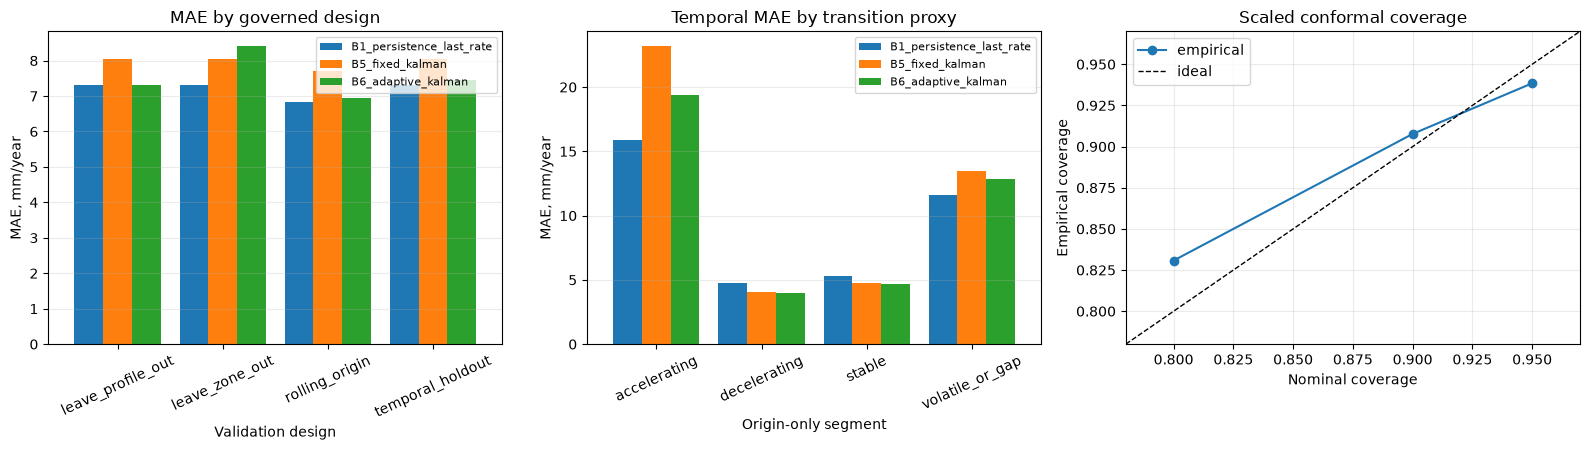

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

mae_table.T.plot(kind='bar', ax=axes[0], width=0.82)
axes[0].set_title('MAE by governed design')
axes[0].set_ylabel('MAE, mm/year')
axes[0].set_xlabel('Validation design')
axes[0].tick_params(axis='x', rotation=25)
axes[0].grid(axis='y', alpha=0.25)

temporal_transition = transition.loc[
    transition['design'].eq('temporal_holdout')
    & transition['scope'].eq('mechanism')
].pivot(index='segment', columns='model_id', values='mae')
temporal_transition.plot(kind='bar', ax=axes[1], width=0.82)
axes[1].set_title('Temporal MAE by transition proxy')
axes[1].set_ylabel('MAE, mm/year')
axes[1].set_xlabel('Origin-only segment')
axes[1].tick_params(axis='x', rotation=25)
axes[1].grid(axis='y', alpha=0.25)

axes[2].plot(intervals['coverage_nominal'], intervals['coverage_empirical'], 'o-', label='empirical')
axes[2].plot([0.78, 0.97], [0.78, 0.97], '--', color='black', linewidth=1, label='ideal')
axes[2].set_xlim(0.78, 0.97)
axes[2].set_ylim(0.78, 0.97)
axes[2].set_title('Scaled conformal coverage')
axes[2].set_xlabel('Nominal coverage')
axes[2].set_ylabel('Empirical coverage')
axes[2].grid(alpha=0.25)
axes[2].legend()

for ax in axes[:2]:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Transition-specific evidence

In [8]:
transition.loc[
    transition['design'].eq('temporal_holdout')
    & transition['scope'].isin(['stable_vs_transition', 'mechanism']),
    ['model_id', 'scope', 'segment', 'rows', 'points', 'profiles', 'mae', 'improvement_vs_b1_percent'],
].round(3)

,model_id,scope,segment,rows,points,profiles,mae,improvement_vs_b1_percent
66,B1_persistence_last_rate,mechanism,accelerating,17,14,5,15.900,0.000
67,B6_adaptive_kalman,mechanism,accelerating,17,14,5,19.406,-22.052
68,B5_fixed_kalman,mechanism,accelerating,17,14,5,23.178,-45.775
69,B6_adaptive_kalman,mechanism,decelerating,11,11,4,4.014,15.765
70,B5_fixed_kalman,mechanism,decelerating,11,11,4,4.035,15.333
71,B1_persistence_last_rate,mechanism,decelerating,11,11,4,4.766,0.000
72,B6_adaptive_kalman,mechanism,stable,88,75,14,4.716,10.852
73,B5_fixed_kalman,mechanism,stable,88,75,14,4.746,10.283
74,B1_persistence_last_rate,mechanism,stable,88,75,14,5.290,0.000
75,B1_persistence_last_rate,mechanism,volatile_or_gap,14,14,9,11.583,0.000


### Interval calibration

In [9]:
intervals.round(3)

,coverage_nominal,rows,coverage_empirical,coverage_gap,mean_width_mm_y,median_width_mm_y,mean_interval_score,qhat
0,0.80,130,0.831,0.031,20.089,18.123,42.139,2.006
1,0.90,130,0.908,0.008,30.279,27.316,60.474,3.023
2,0.95,130,0.938,-0.012,47.090,42.481,82.578,4.701


In [10]:
assert validation_report['status'] == 'PASS'
assert validation_report['summary']['failed'] == 0
assert report['test_data_loaded'] is False
assert report['test_phase_available'] is False
assert holdout['current_t1_test_eligible'] is False
{
    'independent_checks': validation_report['summary'],
    'assessment': validation_report['overall_assessment'],
    'protected_test_unchanged': True,
}

{'independent_checks': {'checks': 169, 'failed': 0},
 'assessment': 'Share with caveats',
 'protected_test_unchanged': True}

## Takeaways

1. **B6 — полезный comparator, но не новый победитель.** Он на 7.25% лучше fixed B5 по temporal MAE и почти равен B1 в leave-profile-out, однако B1 остаётся сильнее на temporal и rolling-origin.
2. **Главная проблема локализована в переходах.** B6 улучшает stable и decelerating segments относительно B1, но заметно проигрывает на accelerating и volatile-or-gap; объединённый transition MAE хуже B1 на 14.25%. Это противоречит требованию улучшения не менее чем на 10%.
3. **Пространственная устойчивость недостаточна.** Leave-zone MAE ухудшается относительно temporal на 12.77% при лимите 5%. Следующая модель должна явно работать с пространственной переносимостью, не вводя идентификаторы зон в estimator features.
4. **Интервальная часть работает как заявлено.** 95% coverage равен 0.938 и попадает в коридор 0.90–0.97, но средняя ширина 47.1 мм/год велика — интервалы честные, но пока не очень точные.
5. **Governance-статус не меняется.** Результат — `validation_recorded`; текущий test остаётся историческим diagnostic-only. До финальной оценки нужен новый future/external holdout либо отдельное документированное решение.